# TASK 1

Parameters picked by gridsearch and its optimized for 'left.jpg' image, this most likey will impacted the performance on other images.

Biggest impact when image were scaled down as details were lost.




Custom Harris - Original: 13 corners detected.
Custom Harris - Rotated: 13 corners detected.
Custom Harris - Scaled Down (50%): 12 corners detected.
Custom Harris - Scaled Up (200%): 14 corners detected.
OpenCV Harris - Original: 272 corners detected.
OpenCV Harris - Rotated: 305 corners detected.
OpenCV Harris - Scaled Down (50%): 269 corners detected.
OpenCV Harris - Scaled Up (200%): 367 corners detected.


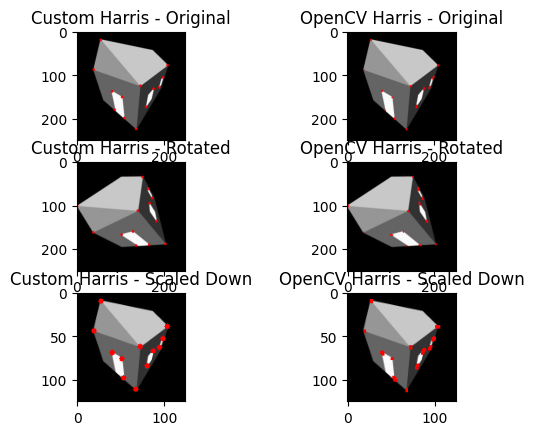

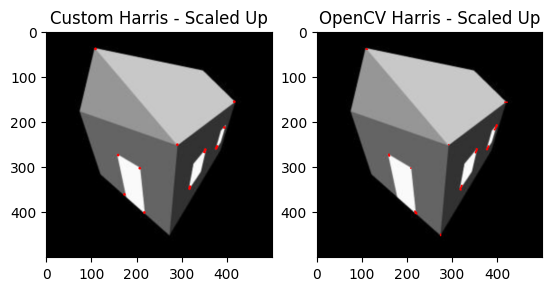

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Custom Harris Corner Detector
def harris_corners(image, k=0.04, threshold=0.05, sobel_ksize=3, gaussian_kernel_size=(5, 5)):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    # Gradients and derivative products
    Ix = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=sobel_ksize)
    Iy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=sobel_ksize)
    Ix2, Iy2, Ixy = Ix**2, Iy**2, Ix*Iy

    # Gaussian filtering
    Sx2 = cv2.GaussianBlur(Ix2, gaussian_kernel_size, 1.5)
    Sy2 = cv2.GaussianBlur(Iy2, gaussian_kernel_size, 1.5)
    Sxy = cv2.GaussianBlur(Ixy, gaussian_kernel_size, 1.5)

 # Harris response
    detM = (Sx2 * Sy2) - (Sxy ** 2)  # Determinant of the structure tensor (M)
    traceM = Sx2 + Sy2               # Trace of the structure tensor (M)
    R = detM - k * (traceM ** 2)     # Harris response calculation

    # Threshold and non-maximum suppression
    dilated_R = cv2.dilate(R, None)
    corners = (R == dilated_R) & (R > threshold * R.max())

    return corners.astype(np.uint8), R

# Mark detected corners
def mark_corners(image, corners):
    for i in range(corners.shape[0]):
        for j in range(corners.shape[1]):
            if corners[i, j]:
                cv2.circle(image, (j, i), 3, (0, 0, 255), -1)
    return image

# Load image
image = cv2.imread('left.jpg')


###################################################

# Custom Harris Detector on Original Image
corners_custom, _ = harris_corners(image)
image_with_corners = mark_corners(image.copy(), corners_custom)
cv2.imwrite('custom_harris_original.png', image_with_corners)
print(f"Custom Harris - Original: {np.sum(corners_custom)} corners detected.")

# Rotate image for custom Harris detection
M = cv2.getRotationMatrix2D((image.shape[1] / 2, image.shape[0] / 2), 45, 1)
rotated_image_custom = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
corners_rotated_custom, _ = harris_corners(rotated_image_custom)
rotated_image_with_corners_custom = mark_corners(rotated_image_custom.copy(), corners_rotated_custom)
cv2.imwrite('custom_harris_rotated.png', rotated_image_with_corners_custom)
print(f"Custom Harris - Rotated: {np.sum(corners_rotated_custom)} corners detected.")

# Scale the image (downscaled to 50%) for custom Harris detection
scaled_image_custom_down = cv2.resize(image, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)
corners_scaled_custom_down, _ = harris_corners(scaled_image_custom_down)
scaled_image_with_corners_custom_down = mark_corners(scaled_image_custom_down.copy(), corners_scaled_custom_down)
cv2.imwrite('custom_harris_scaled_down.png', scaled_image_with_corners_custom_down)
print(f"Custom Harris - Scaled Down (50%): {np.sum(corners_scaled_custom_down)} corners detected.")

# Scale the image (upscaled to 200%) for custom Harris detection
scaled_image_custom_up = cv2.resize(image, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_LINEAR)
corners_scaled_custom_up, _ = harris_corners(scaled_image_custom_up)
scaled_image_with_corners_custom_up = mark_corners(scaled_image_custom_up.copy(), corners_scaled_custom_up)
cv2.imwrite('custom_harris_scaled_up.png', scaled_image_with_corners_custom_up)
print(f"Custom Harris - Scaled Up (200%): {np.sum(corners_scaled_custom_up)} corners detected.")

# OpenCV Harris Corner Detector on Original Image
gray = np.float32(cv2.cvtColor(image, cv2.COLOR_BGR2GRAY))
dst = cv2.cornerHarris(gray, 2, 3, 0.04) # Built in
dst = cv2.dilate(dst, None)
image_builtin = image.copy()
image_builtin[dst > 0.01 * dst.max()] = [0, 0, 255]
cv2.imwrite('opencv_harris_original.png', image_builtin)
print(f"OpenCV Harris - Original: {np.sum(dst > 0.01 * dst.max())} corners detected.")

# Rotate image for OpenCV Harris detection
rotated_image_builtin = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
gray_rotated = np.float32(cv2.cvtColor(rotated_image_builtin, cv2.COLOR_BGR2GRAY))
dst_rotated = cv2.cornerHarris(gray_rotated, 2, 3, 0.04)
dst_rotated = cv2.dilate(dst_rotated, None)
rotated_image_builtin[dst_rotated > 0.01 * dst_rotated.max()] = [0, 0, 255]
cv2.imwrite('opencv_harris_rotated.png', rotated_image_builtin)
print(f"OpenCV Harris - Rotated: {np.sum(dst_rotated > 0.01 * dst_rotated.max())} corners detected.")

# Scale the image (downscaled to 50%) for OpenCV Harris detection
scaled_image_builtin_down = cv2.resize(image, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)
gray_scaled_down = np.float32(cv2.cvtColor(scaled_image_builtin_down, cv2.COLOR_BGR2GRAY))
dst_scaled_down = cv2.cornerHarris(gray_scaled_down, 2, 3, 0.04)
dst_scaled_down = cv2.dilate(dst_scaled_down, None)
scaled_image_builtin_down[dst_scaled_down > 0.01 * dst_scaled_down.max()] = [0, 0, 255]
cv2.imwrite('opencv_harris_scaled_down.png', scaled_image_builtin_down)
print(f"OpenCV Harris - Scaled Down (50%): {np.sum(dst_scaled_down > 0.01 * dst_scaled_down.max())} corners detected.")

# Scale the image (upscaled to 200%) for OpenCV Harris detection
scaled_image_builtin_up = cv2.resize(image, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_LINEAR)
gray_scaled_up = np.float32(cv2.cvtColor(scaled_image_builtin_up, cv2.COLOR_BGR2GRAY))
dst_scaled_up = cv2.cornerHarris(gray_scaled_up, 2, 3, 0.04)
dst_scaled_up = cv2.dilate(dst_scaled_up, None)
scaled_image_builtin_up[dst_scaled_up > 0.01 * dst_scaled_up.max()] = [0, 0, 255]
cv2.imwrite('opencv_harris_scaled_up.png', scaled_image_builtin_up)
print(f"OpenCV Harris - Scaled Up (200%): {np.sum(dst_scaled_up > 0.01 * dst_scaled_up.max())} corners detected.")

# Plot results
plt.subplot(3, 2, 1)
plt.imshow(cv2.cvtColor(image_with_corners, cv2.COLOR_BGR2RGB))
plt.title('Custom Harris - Original')

plt.subplot(3, 2, 2)
plt.imshow(cv2.cvtColor(image_builtin, cv2.COLOR_BGR2RGB))
plt.title('OpenCV Harris - Original')

plt.subplot(3, 2, 3)
plt.imshow(cv2.cvtColor(rotated_image_with_corners_custom, cv2.COLOR_BGR2RGB))
plt.title('Custom Harris - Rotated')

plt.subplot(3, 2, 4)
plt.imshow(cv2.cvtColor(rotated_image_builtin, cv2.COLOR_BGR2RGB))
plt.title('OpenCV Harris - Rotated')

plt.subplot(3, 2, 5)
plt.imshow(cv2.cvtColor(scaled_image_with_corners_custom_down, cv2.COLOR_BGR2RGB))
plt.title('Custom Harris - Scaled Down')

plt.subplot(3, 2, 6)
plt.imshow(cv2.cvtColor(scaled_image_builtin_down, cv2.COLOR_BGR2RGB))
plt.title('OpenCV Harris - Scaled Down')

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(scaled_image_with_corners_custom_up, cv2.COLOR_BGR2RGB))
plt.title('Custom Harris - Scaled Up')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(scaled_image_builtin_up, cv2.COLOR_BGR2RGB))
plt.title('OpenCV Harris - Scaled Up')

plt.show()


# TASK 2

SIFT shine here on Note dame as it has different scale and rotation and complexity sensitivity robustness.


 SIFT Keypoints for 'left.jpg' and 'right.jpg':
SIFT Keypoints Detection:
Image 1 (left.jpg): Number of keypoints: 45
Image 2 (right.jpg): Number of keypoints: 44


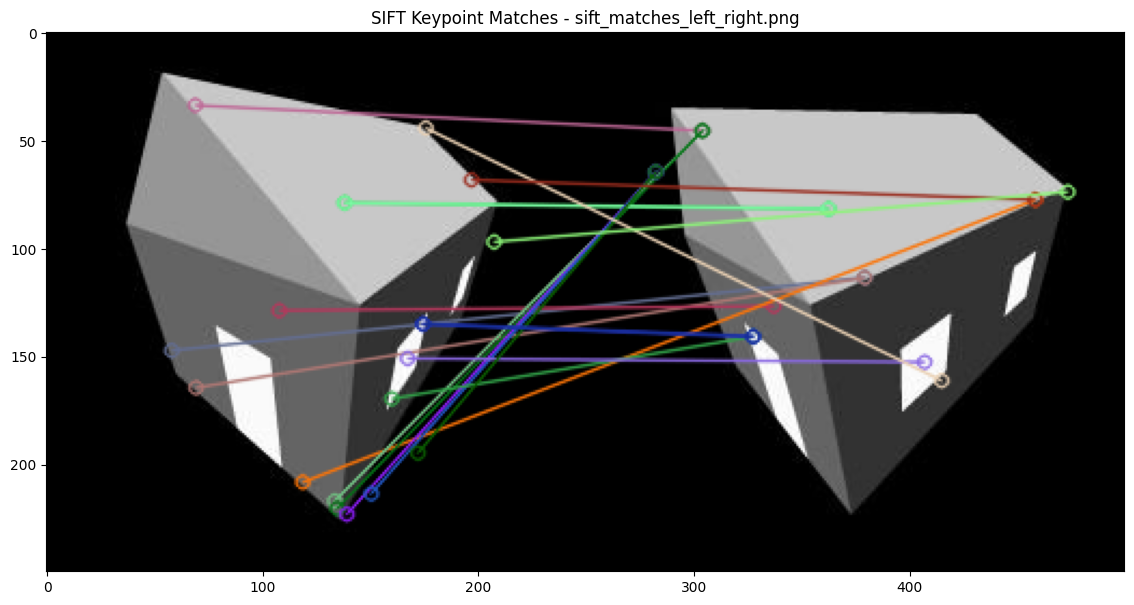


 Harris Corners for 'left.jpg' and 'right.jpg':
Harris Corners Detection:
Image 1 (left.jpg): Number of Harris corners: 224
Image 2 (right.jpg): Number of Harris corners: 149


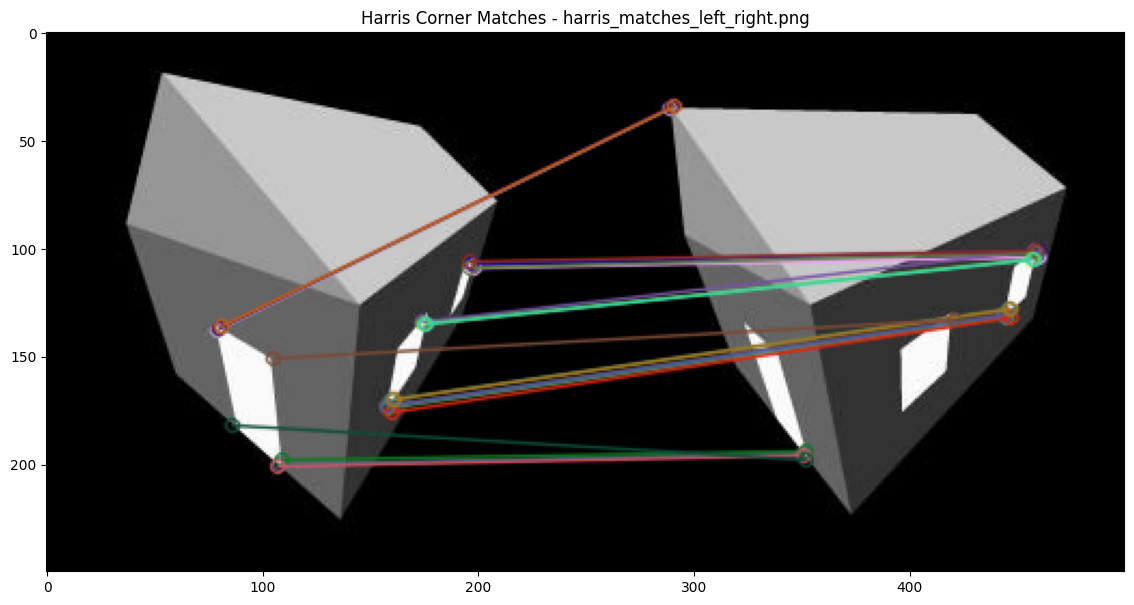


 SIFT Keypoints for 'notre_dame1.jpg' and 'notre_dame2.jpg':
SIFT Keypoints Detection:
Image 1 (notre_dame1.jpg): Number of keypoints: 20368
Image 2 (notre_dame2.jpg): Number of keypoints: 24548


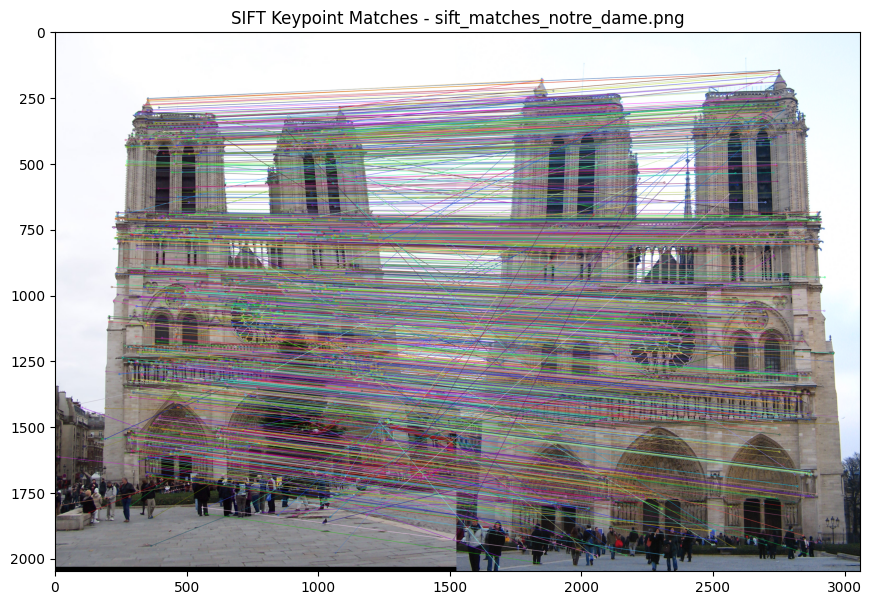


 Harris Corners for 'notre_dame1.jpg' and 'notre_dame2.jpg':
Harris Corners Detection:
Image 1 (notre_dame1.jpg): Number of Harris corners: 11093
Image 2 (notre_dame2.jpg): Number of Harris corners: 11212


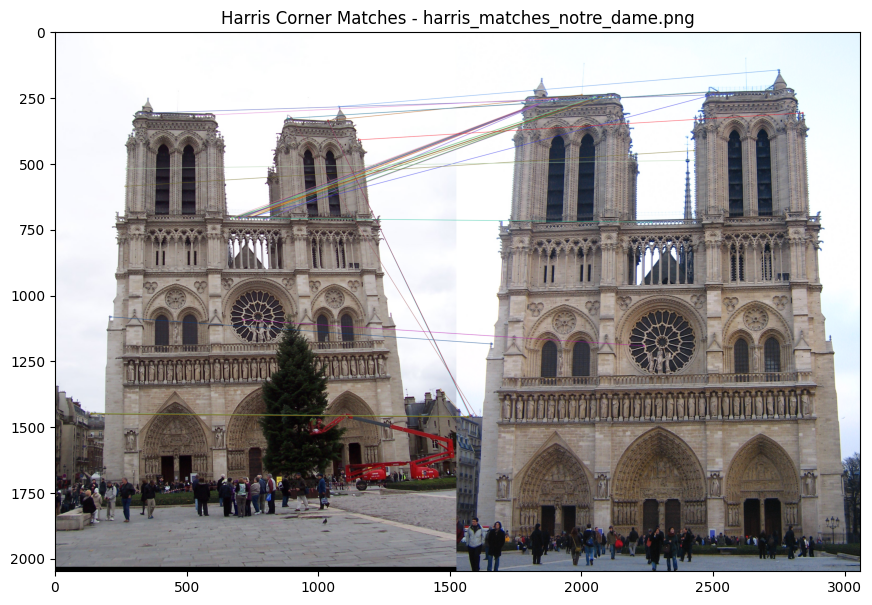

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sift_feature_detection(image1_path, image2_path, output_image_name):
    # Load images
    image1 = cv2.imread(image1_path)
    image2 = cv2.imread(image2_path)
    gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

    # SIFT feature detection
    sift = cv2.SIFT_create()
    keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
    keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

    # Print basic statistics
    print(f"SIFT Keypoints Detection:")
    print(f"Image 1 ({image1_path}): Number of keypoints: {len(keypoints1)}")
    print(f"Image 2 ({image2_path}): Number of keypoints: {len(keypoints2)}")

    # Matching SIFT descriptors using FLANN matcher
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(descriptors1, descriptors2, k=2)
    good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]

    # Visualization of SIFT keypoint matches
    image_matches = cv2.drawMatches(image1, keypoints1, image2, keypoints2, good_matches, None, flags=2)

    # Save the SIFT matches image
    cv2.imwrite(output_image_name, image_matches)

    # Display the image
    plt.figure(figsize=(15, 7))
    plt.imshow(cv2.cvtColor(image_matches, cv2.COLOR_BGR2RGB))
    plt.title(f"SIFT Keypoint Matches - {output_image_name}")
    plt.show()

# Function to detect, match, visualize, and save Harris corners with statistics
def harris_feature_detection(image1_path, image2_path, harris_threshold_factor, output_image_name):
    # Load images
    image1 = cv2.imread(image1_path)
    image2 = cv2.imread(image2_path)
    gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

    # Harris corner detection
    def detect_harris_corners(gray_image, threshold_factor):
        harris_corners = cv2.cornerHarris(gray_image, blockSize=2, ksize=3, k=0.04)
        harris_corners = cv2.dilate(harris_corners, None)
        threshold = threshold_factor * harris_corners.max()
        return np.argwhere(harris_corners > threshold)  # Return corner positions

    # Increase the threshold factor to reduce the number of detected corners
    corners1 = detect_harris_corners(gray1, harris_threshold_factor)
    corners2 = detect_harris_corners(gray2, harris_threshold_factor)

    # Convert corner points to cv2.KeyPoint objects
    keypoints1 = [cv2.KeyPoint(x=float(x), y=float(y), size=1) for y, x in corners1]
    keypoints2 = [cv2.KeyPoint(x=float(x), y=float(y), size=1) for y, x in corners2]

    print(f"Harris Corners Detection:")
    print(f"Image 1 ({image1_path}): Number of Harris corners: {len(keypoints1)}")
    print(f"Image 2 ({image2_path}): Number of Harris corners: {len(keypoints2)}")

    # ORB descriptors for Harris corners
    orb = cv2.ORB_create()
    keypoints1, descriptors1 = orb.compute(gray1, keypoints1)
    keypoints2, descriptors2 = orb.compute(gray2, keypoints2)

    # BFMatcher for Harris corners using ORB descriptors
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(descriptors1, descriptors2)
    matches = sorted(matches, key=lambda x: x.distance)

    # Visualization of Harris corner matches
    image_matches = cv2.drawMatches(image1, keypoints1, image2, keypoints2, matches[:50], None, flags=2)

    # Save the Harris corner matches image
    cv2.imwrite(output_image_name, image_matches)

    # Display the image
    plt.figure(figsize=(15, 7))
    plt.imshow(cv2.cvtColor(image_matches, cv2.COLOR_BGR2RGB))
    plt.title(f"Harris Corner Matches - {output_image_name}")
    plt.show()

# SIFT and Harris pipelines for 'left.jpg' and 'right.jpg'
print("\n SIFT Keypoints for 'left.jpg' and 'right.jpg':")
sift_feature_detection('left.jpg', 'right.jpg', 'sift_matches_left_right.png')

print("\n Harris Corners for 'left.jpg' and 'right.jpg':")
harris_feature_detection('left.jpg', 'right.jpg', harris_threshold_factor=0.05, output_image_name='harris_matches_left_right.png')

# SIFT and Harris pipelines for 'notre_dame1.jpg' and 'notre_dame2.jpg'
print("\n SIFT Keypoints for 'notre_dame1.jpg' and 'notre_dame2.jpg':")
sift_feature_detection('notre_dame1.jpg', 'notre_dame2.jpg', 'sift_matches_notre_dame.png')

print("\n Harris Corners for 'notre_dame1.jpg' and 'notre_dame2.jpg':")
harris_feature_detection('notre_dame1.jpg', 'notre_dame2.jpg', harris_threshold_factor=0.05, output_image_name='harris_matches_notre_dame.png')
